# Manual Implementation of Support Vector Machines

[Use numpy for all questions (`sklearn` is only allowed to *check* your results)]

In [2]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)

Here are two plotting helpers, given so you do not waste time on `matplotlib`.

*`plot_data` draws the points, `plot_boundary` draws the decision boundary $f(x) = 0$ (solid) and the two edges of the street $f(x) = \pm 1$ (dashed) of any score function `f`.*

In [3]:
def plot_data(X, y):
    plt.plot(X[y > 0, 0], X[y > 0, 1], 'o', color='crimson', ms=5, label='$y = +1$')
    plt.plot(X[y < 0, 0], X[y < 0, 1], 's', color='royalblue', ms=5, label='$y = -1$')
    plt.xlabel('$x_1$')
    plt.ylabel('$x_2$')


def plot_boundary(f, X, y, res=300, pad=1.0, title=None):
    g1 = np.linspace(X[:, 0].min() - pad, X[:, 0].max() + pad, res)
    g2 = np.linspace(X[:, 1].min() - pad, X[:, 1].max() + pad, res)
    G1, G2 = np.meshgrid(g1, g2)
    Z = f(np.c_[G1.ravel(), G2.ravel()]).reshape(G1.shape)
    plt.contourf(G1, G2, Z, levels=[-1e9, 0, 1e9],
                 colors=['royalblue', 'crimson'], alpha=0.12)
    plt.contour(G1, G2, Z, levels=[-1, 0, 1], colors='k',
                linestyles=['--', '-', '--'], linewidths=[1, 2, 1])
    plot_data(X, y)
    if title:
        plt.title(title)

Create a small 2D binary classification problem: $N = 100$ points, two Gaussian blobs, one centred on $(2, 2)$, and the other on $(-2, -1)$, both with unit variance.
Use the function `np.random.randn`.

Labels must be $y_i \in \{-1, +1\}$ (**not** $\{0, 1\}$, since the whole SVM algebra relies on the $\pm 1$ coding).

Plot the data to check that the two classes are (almost) linearly separable.

### Which line?

Before optimising anything:
when the classes are separable there is not *one* separating line, there are infinitely many, and all of them have **zero** training error.

Find a few different pairs $(w, b)$ that separate the training set perfectly.
The simplest way is to draw $(w, b)$ at random and keep the ones for which $y_i (w^T x_i + b) > 0$ for **all** $i$.
Plot the boundary on top of the data.

*(Rerun this cell multiple time to see that different pairs of $(w, b)$ can work.)*

All of these have zero training error, yet they are clearly not all equally good.
We will design a criterion to rank them apart.

### The hinge loss

Define the *margin* of a point as $m_i = y_i f(x_i) = y_i (w^T x_i + b)$: it is positive when the point is
correctly classified, and larger than $1$ when the point is correctly classified **and** outside the street.

Define the hinge loss $\ell(m) = \max(0, 1 - m)$ and plot it against the $0/1$ loss
$\mathbb{1}[m < 0]$ and the logistic loss $\log_2(1 + e^{-m})$ for $m \in [-2, 3]$.

Write the soft-margin SVM objective

$$ J(w, b) \;=\; \frac{1}{2}\lVert w \rVert^2 \;+\; C \sum_{i=1}^{N} \max\big(0,\; 1 - y_i (w^T x_i + b)\big) $$

as a function `objective(X, y, w, b, C)`.

The first term is the regularizer (it widens the street), the second is the data-fit term, and $C$ sets the exchange rate between the two.

Compute the gradient of $J$ with respect to $w$ and $b$.

The hinge is not differentiable at $m = 1$, but that single point does not matter in practice:
take the derivative to be $0$ when $m_i > 1$ and $-1$ when $m_i < 1$ (this is a *sub*gradient).

Writing $a_i = \mathbb{1}[m_i < 1]$ for the indicator of the active points:

$$ \frac{\partial J}{\partial w} = w - C \sum_i a_i\, y_i\, x_i \qquad
   \frac{\partial J}{\partial b} = - C \sum_i a_i\, y_i $$

Implement `gradients(X, y, w, b, C)` **without any python loop**.

Check your gradient numerically, with a centered finite difference:
$$ \frac{\partial J}{\partial \theta} \approx \frac{J(\theta + \varepsilon) - J(\theta - \varepsilon)}{2\varepsilon} $$
with $\varepsilon = 10^{-6}$.

Do it at a random $(w, b)$.

### Training

Write a `train_linear_svm(X, y, C, lr, n_epochs)` function that starts from $w = 0$, $b = 0$, performs
gradient descent, and returns $w$, $b$ and the history of the objective.

Train with $C = 1$, `lr = 1e-3` and $2000$ epochs, and plot the objective (use a `semilogy`).

Plot the decision boundary and the two edges of the street with `plot_boundary`.

Then find the **support vectors** (the points with $m_i \leq 1$, up to a small tolerance), as well as the width of the street $2 / \lVert w \rVert$.

Now the punchline. Re-train the model **on the support vectors only**, and compare $(w, b)$ with the model
trained on the full dataset.

We threw away $97\%$ of the training data and got the same model (up to a multiplication constant).

Check your implementation against `sksvm = sklearn.svm.SVC(kernel='linear', C=1.0)`:
compare the coefficients (`sksvm.coef_`), and the intercept (`sksvm.intercept_`).

In [4]:
import sklearn

# sksvm = sklearn.svm.SVC(kernel='linear', C=1.0)
# sksvm.fit(X, y)
# sksvm.coef_, sksvm.intercept_

### $C$: how much misbehaviour do you allow?

Real data overlaps, so "the widest street with nothing inside it" usually has no solution at all.

The $C$ term is what makes the margin *soft*: points are allowed inside the street, or even on the wrong side, at a cost.

Build an **overlapping** dataset ($100$ points per class, centred on $(1.2, 1.2)$ and $(-1.2, -1.2)$, unit variance) and check on the plot that no line separates it.

Fit the model on this dataset for $C \in \{0.01, 0.1, 1, 10\}$ and plot the four boundaries side by side, circling the support vectors.

For each $C$, print the street width $2/\lVert w \rVert$, the number of support vectors and the training accuracy.

*Careful: the gradient is proportional to $C$, so a large $C$ needs a smaller learning rate.*
*Using `lr = 1e-3 / max(C, 1)` and $4000$ epochs should work.*


### Alway scale your columns

The SVM measures distances, so the scale of the columns is not neutral.

Take the overlapping dataset and multiply the **second** column by $100$ (imagine one feature is in metres and the other in centimetres).
Fit the model with $C = 1$ on the rescaled data, and print the training accuracy.

Then fit it again on the *standardized* rescaled data (subtract the mean, divide by the standard deviation, column by column).

-----

## Part 2 (going non-linear: the kernel trick)

**We will now fit an SVM whose boundary is not a straight line, without ever building the features that would make it straight.**

Build a dataset that no line can separate:
two concentric rings ($100$ points each, radii $3$ and $1$, gaussian noise of standard deviation $0.25$).
Sample the angles uniformly in $[0, 2\pi)$.

Fit the linear SVM on it and look at the result.

The easiest fix is to **add a column by hand**.

Define the lift
$$ \varphi(x) = \big(x_1,\; x_2,\; x_1^2 + x_2^2\big) \in \mathbb{R}^3 $$

Fit the *same* linear SVM on $\varphi(X)$ (use `np.apply_along_axis`);
then, plot the resulting boundary back in the original 2D plane
(pass `lambda Z: np.apply_along_axis(phi, 1, Z) @ w + b` to `plot_boundary`).

A flat plane in the lifted space became a circle back in 2D.

The added column was the right one, but in general nobody knows what feature to build.

The safe answer is to add **every** product of degree $\leq d$ and let the SVM sort out which ones matter.
But that lift has $\binom{p+d}{d}$ coordinates, and it explodes:

| columns $p$ | degree $d$ | size of $\varphi(x)$ |
|---|---|---|
| 2 | 2 | 6 |
| 10 | 3 | 286 |
| 100 | 3 | 176 851 |
| 1000 | 5 | 8 459 043 543 951 |

The RBF kernel is infinite-dimensional ($d=\infty$), so no amount of memory is enough.

The objective, the gradient and the score never touch a lifted point on its own: they only ever use **dot products** $\varphi(x)^T \varphi(x')$ between pairs of training points.
And those dot products are often cheap to compute *without* building $\varphi$.

For instance, with $p = 2$ and
$$ \varphi(x) = \big(1,\; \sqrt{2}x_1,\; \sqrt{2}x_2,\; x_1^2,\; x_2^2,\; \sqrt{2}x_1x_2\big) $$
a direct expansion gives
$$ \varphi(x)^T \varphi(x') \;=\; \big(x^T x' + 1\big)^2 $$

The left-hand side costs $6$ multiplications and a $6$-dimensional vector; the right-hand side costs $2$ multiplications and no vector at all.
That is the **kernel trick**: replace every $\varphi(x)^T \varphi(x')$ by a function $K(x, x')$ that returns the same number directly.

The downside: scoring a new point costs a pass over the training set instead of a single dot product.
This is good when $p \gg n$, a bad one when $n$ is huge.

### Kernels

Write three kernels, each taking two matrices `A` $(n \times p)$ and `B` $(m \times p)$ and returning the $n \times m$ matrix of pairwise values:

- linear: $K(x, x') = x^T x'$
- polynomial: $K(x, x') = (\gamma\, x^T x' + c_0)^d$
- RBF (gaussian): $K(x, x') = \exp(-\gamma \lVert x - x' \rVert^2)$

Call them `linear_kernel(A, B)`, `poly_kernel(A, B, degree=3, gamma=1.0, coef0=1.0)` and `rbf_kernel(A, B, gamma=1.0)`, so that the tests in the next cell can check them.

```python
rng = np.random.default_rng(0)
A = rng.normal(size=(5, 3))
B = rng.normal(size=(4, 3))

# linear 1 -- right shape, right values
K = linear_kernel(A, B)
print(K.shape) # -> (5, 4)
print(K[0, 0], K[2, 3], K[4, 1]) # -> -0.222735, 1.790389, -1.025004

# linear 2 -- K(A, A) is symmetric and its diagonal holds the squared norms
KA = linear_kernel(A, A)

print(KA - KA.T) # -> zeros
print(np.diag(KA) - (A**2).sum(axis=1)) # -> zeros
```

```python
# --- check your three kernels (run this once they are written) ---
rng = np.random.default_rng(0)
A = rng.normal(size=(5, 3))
B = rng.normal(size=(4, 3))

# poly 1 -- degree 1 with gamma=1, coef0=0 collapses to the linear kernel
K = poly_kernel(A, B, degree=1, gamma=1.0, coef0=0.0)
print(K - linear_kernel(A, B)) # -> zeros

# poly 2 -- right shape, right values
K = poly_kernel(A, B, degree=3, gamma=0.5, coef0=1.0)
print(K.shape) # -> (5, 4)
print(K[0, 0], K[2, 3], K[4, 1]) # -> 0.701725, 6.807088, 0.115856
```

For the RBF, do **not** write a loop: expand $\lVert x - x' \rVert^2 = \lVert x \rVert^2 + \lVert x' \rVert^2 - 2 x^T x'$.

In `numpy`, `(A**2).sum(axis=1)` gives the $n$ squared norms of `A` and `(B**2).sum(axis=1)` the $m$ squared norms of `B`:
turn the first into a column (`[:, None]`) and the second into a row (`[None, :]`) so that both broadcast against the $n \times m$ matrix `A @ B.T`.

```python
# --- check your three kernels (run this once they are written) ---
rng = np.random.default_rng(0)
A = rng.normal(size=(5, 3))
B = rng.normal(size=(4, 3))

# rbf 1 -- right shape, right values
K = rbf_kernel(A, B, gamma=0.7)
print(K.shape)                          # -> (5, 4)
print(K[0, 0], K[2, 3], K[4, 1])        # -> 0.279446, 0.536434, 0.000724

# rbf 2 -- a point is maximally similar to itself
KA = rbf_kernel(A, A, gamma=0.7)
KB = rbf_kernel(B, B, gamma=0.7)
print(np.diag(KA), np.diag(KB))                      # -> all 1
```

A kernel is just a **similarity score**: one number saying how alike two rows count as.

Display the $200 \times 200$ Gram matrix $K_{ij} = K(x_i, x_j)$ of the rings dataset with the RBF kernel ($\gamma = 0.5$) using `plt.imshow`.
The points are already sorted by class, so soe structure should appear.

### The SVM in kernel form

We cannot store $w$ any more, but we do not have to.

The *representer theorem* say the optimal $w$ is alway a linear combination of the training points, $w = \sum_i \alpha_i \varphi(x_i)$.

Hence, the score becomes
$$ f(x) \;=\; \sum_{i=1}^{N} \alpha_i K(x_i, x) \;+\; b \qquad\text{and}\qquad \lVert w \rVert^2 = \alpha^T K \alpha $$

The unknowns are now the $N$ numbers $\alpha$ and the bias $b$.
Note that there is no $\varphi$ anywhere, only $K(x_i, x)$.

Write the kernel objective and its gradient:

$$ J(\alpha, b) = \tfrac{1}{2}\, \alpha^T K \alpha + C \sum_i \max\big(0, 1 - y_i f_i\big), \qquad f = K\alpha + b $$

$$ \frac{\partial J}{\partial \alpha} = K\alpha - C\, K (a \odot y), \qquad \frac{\partial J}{\partial b} = -C \sum_i a_i y_i $$

where $a_i = \mathbb{1}[y_i f_i < 1]$, as before.

Implement `k_objective(K, y, alpha, b, C)` and `k_gradients(K, y, alpha, b, C)`.

```python
rng = np.random.default_rng(8)
A_test = rng.normal(size=(6, 3))
K_test = A_test @ A_test.T
y_test = np.array([1., 1., 1., -1., -1., -1.])
alpha_test = rng.normal(size=6) * 0.5
b_test, C_test = 0.3, 1.0

# objective 1 -- at alpha = 0, b = 0 every margin is 0, so every hinge is 1: J = C * N
print(k_objective(K_test, y_test, np.zeros(6), 0.0, C_test))          # -> 6.0
# objective 2 -- value at a random (alpha, b)
print(k_objective(K_test, y_test, alpha_test, b_test, C_test))                  # -> 10.619915
```

```python
rng = np.random.default_rng(8)
A_test = rng.normal(size=(6, 3))
K_test = A_test @ A_test.T
y_test = np.array([1., 1., 1., -1., -1., -1.])
alpha_test = rng.normal(size=6) * 0.5
b_test, C_test = 0.3, 1.0

g_a, g_b = k_gradients(K_test, y_test, alpha_test, b_test, C_test)
print(g_a.shape, g_a[:3], g_b) # -> 6, [-21.933926 -15.963063   3.941986], 1.0
```

Write `train_kernel_svm(K, y, C, lr, n_epochs)` (start from $\alpha = 0$, $b = 0$).
Train on the rings with the RBF kernel, $\gamma = 0.5$, $C = 1$, `lr = 1e-3`, $3000$ epochs.

Plot the objective evolution through the epochs.

Compute the accuracy.
The score is now
$$ f(z) = \sum_{i=1}^{N} \alpha_i K(x_i, z) + b $$
For the **training** points this is exactly $f = K\alpha + b$, since $K$ (the Gram matrix of the training set against itself).

A point is well classified when $y_i f_i > 0$.

Plot the decision boundary.

Careful: `plot_boundary` evaluates your score function on a $300 \times 300$ grid, and those $90\,000$ points are **not** the training points.
The $K$ you trained on is of no use here.
What you need is the kernel between the **grid** and the **training set**.

If `Z` is the $(m, 2)$ grid and `X` the $(N, 2)$ training set, then `rbf_kernel(Z, X, gamma)` has shape $(m, N)$:
one row per point to score, one column per training point.

The score is then
```python
rbf_kernel(Z, X, gamma) @ alpha + b      # (m, N) @ (N,) -> (m,)
```

Write a helper that takes the kernel as an argument: `kernel_score(Z, X_train, alpha, b, kernel)`; 
and pass `lambda Z: kernel_score(Z, X, a, b, lambda A, B: rbf_kernel(A, B, 0.5))` to `plot_boundary`.

Sanity check against `sklearn.svm.SVC(kernel='rbf', gamma=0.5, C=1.0)`.

_We ran a gradient descent for $3000$ epochs, while `sklearn` solves the dual problem exactly, so solutions should be close, but might not match exactly._
_(Note that as long as signs are matching, classification will be the same)_

z = [0.0, 0.0] | ours = -1.8934 ; sklearn = -1.7645
z = [3.0, 0.0] | ours = +1.1128 ; sklearn = +1.1297
z = [2.0, 0.0] | ours = -0.0705 ; sklearn = -0.0292


### Comparing kernels

Here is a non-linear dataset: two interleaved moons ($100$ points per class, gaussian noise $0.2$):

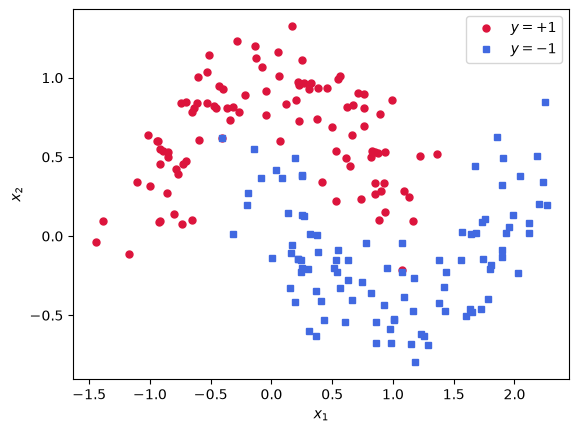

In [40]:
N = 100
noise = 0.2
t = np.linspace(0, np.pi, N)

X1 = np.stack([np.cos(t), np.sin(t)], axis=1)             # (N, 2) upper half of the unit circle
X2 = np.stack([1 - np.cos(t), 0.5 - np.sin(t)], axis=1)   # (N, 2) the second moon
X = np.concat([X1, X2], axis=0) + np.random.randn(2*N, 2) * noise
y = np.concat([np.ones(N), -np.ones(N)])

plot_data(X, y)
plt.legend()
plt.show()

Here are some kernels to try out on this dataset: (plot separation and compute accuracy for each)
- `linear` (with `lr=1e-4`)
- polynomial $d = 2$, (with `lr=1e-5`)
- polynomial $d = 3$,  (with `lr=3e-6`)
- RBF $\gamma = 0.1$ (with  `lr=1e-4`)
- RBF $\gamma = 1$ (with `lr=3e-4`)
- RBF $\gamma = 100$ (with `lr=1e-3`)

Keep $C = 1$ and $10 000$ epochs everywhere.

### Bonus: more than two classes

An SVM is intrinsically binary.
The usual fix is **one-vs-rest**: for $k$ classes, train $k$ binary SVMs, each separating one class from all the others, and predict the class whose score is the highest.

In [42]:
def plot_data3(X, y):
    sel1 = y > 0.5
    sel_1 = y < -0.5
    sel0 = ~(sel1 | sel_1)
    plt.plot(X[sel1, 0], X[sel1, 1], 'o', color='crimson', ms=5, label='$y = +1$')
    plt.plot(X[sel_1, 0], X[sel_1, 1], 's', color='royalblue', ms=5, label='$y = -1$')
    plt.plot(X[sel0, 0], X[sel0, 1], '^', color='seagreen', ms=5, label='$y = 0$')
    plt.xlabel('$x_1$')
    plt.ylabel('$x_2$')
    plt.legend()

def plot_boundary3(f, X, y, classes, res=300, pad=1.0, title=None):
    """Colour each point of the plane by the class with the highest score.

    `f(Z)` takes an (m, 2) array of points and returns an (m, k) array of scores,
    one column per entry of `classes`.
    """
    g1 = np.linspace(X[:, 0].min() - pad, X[:, 0].max() + pad, res)
    g2 = np.linspace(X[:, 1].min() - pad, X[:, 1].max() + pad, res)
    G1, G2 = np.meshgrid(g1, g2)
    S = np.asarray(f(np.c_[G1.ravel(), G2.ravel()]))
    Z = S.argmax(axis=1).reshape(G1.shape)
    palette = {1: 'crimson', -1: 'royalblue', 0: 'seagreen'}
    plt.contourf(G1, G2, Z, levels=np.arange(len(classes) + 1) - 0.5,
                 colors=[palette[c] for c in classes], alpha=0.12)
    plot_data3(X, y)
    if title:
        plt.title(title)

Build three gaussian blobs ($60$ points each, centred on $(0, 2)$, $(2, -1)$ and $(-2, -1)$, standard deviation $0.95$).

For each class $c \in \{0, +1, -1\}$, relabel the data so that class $c$ is the positive one and the two others are negative (use `np.where(y == c, 1., -1.)`).

Then, train a linear SVM on that, and show the binary boundaries for each class (`C = 1`, `lr = 1e-3`, $2000$ epochs work well).

Keep the three $(w_c, b_c)$ in a list.
The score of class $c$ at a point $z$ is the usual $w_c^T z + b_c$, and the prediction is the class with the **highest** score.

Create a scoring function `scores(Z, ws, bs)` that takes an $(m, 2)$ array of points, a list of $k$ `ws`/`bs`, and returns an $(m, k)$ array of scores.

Also create a prediction function `prediction(Z, ws, bs, classes)` that predict the class with higher score, and compute the accuracy on the training set.

Use `plot_boundary3` to plot the boundaries.